In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ee
import geemap
import xesmf as xe
import numpy as np 
from matplotlib.patches import Rectangle
import fiona
from shapely.geometry import shape, Point
from shapely.ops import unary_union
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import xesmf as xe
from shapely import vectorized
from scipy.ndimage import binary_dilation
from datetime import datetime
from dbfread import DBF
import pandas as pd
from xhistogram.xarray import histogram
from tqdm import tqdm

## Default Model Grid  
1x1

In [7]:
# Create a regional regular latitude longitude grid of 1 degree resolution
#  xe.util.cf_grid_2d(lon0_b, lon1_b, d_lon, lat0_b, lat1_b, d_lat)
target_grid = xe.util.cf_grid_2d(0, 360, 1, -90, 90, 1)
target_grid.to_netcdf("/Volumes/Expansion/GCHI/inputs/maskdata/prod/gchi_targetgrid_1x1_global_20260326.nc")

# Land mask

Text(0.5, 1.0, 'Cell is land if any land is in cell (10m shape res)')

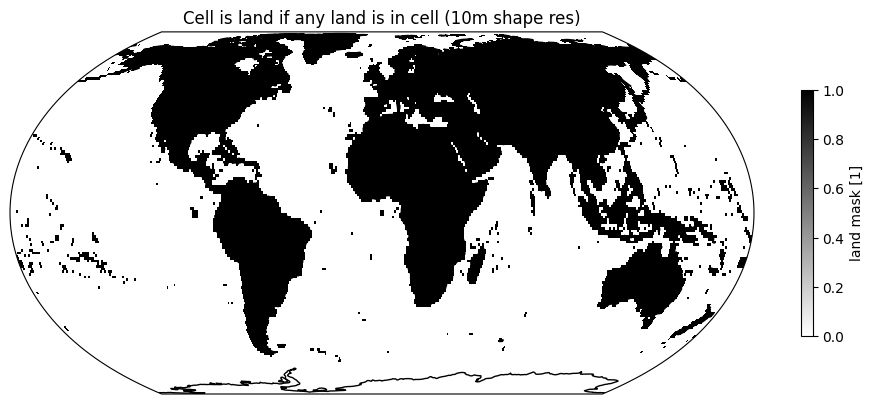

In [34]:
grid = xr.open_dataset("../prod/gchi_targetgrid_1x1_global_20260326.nc")
lons = grid.lon.values
lats = grid.lat.values

with fiona.open("/vsicurl/https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/10m_physical/ne_10m_land.shp") as src:
    geometries = [shape(f["geometry"]) for f in src]

lons_180 = (lons + 180) % 360 - 180
lats_nn = np.sort(lats)[::-1]

transform = from_bounds(-180, -90, 180, 90, len(lons_180), len(lats_nn))
mask = rasterize(
    ((g, 1) for g in geometries),
    out_shape=(len(lats_nn), len(lons_180)),
    transform=transform,
    fill=0,
    all_touched=True,
    dtype="uint8",
).astype(bool)

ds = xr.DataArray(mask, coords=[lats_nn, lons_180], dims=["lat", "lon"]).to_dataset(name="land_mask")
ds = ds.reindex(lat=lats, lon=lons_180[np.argsort(lons_180)])
ds = ds.assign_coords(lon=lons)
ds = ds.where(ds.lat > -60, 0) # mask antarctica

ds["lat"].attrs = {"units": "degrees_north", "standard_name": "latitude",  "long_name": "latitude",  "axis": "Y"}
ds["lon"].attrs = {"units": "degrees_east",  "standard_name": "longitude", "long_name": "longitude", "axis": "X"}
ds["land_mask"].attrs = {
    "long_name":     "land mask",
    "standard_name": "land_binary_mask",
    "units":         "1",
    "flag_values":   "0 1",
    "flag_meanings": "ocean land",
    "source":        "Natural Earth 10m land polygons (ne_10m_land.shp)",
    "rasterize":     "all_touched=True — cell is land if any part overlaps a land polygon",
}
ds.attrs = {
    "title":       "Land boolean mask",
}
ds.to_netcdf("../prod/land_mask_any_touch_20260401.nc")

fig, ax = plt.subplots(figsize=(12,8),subplot_kw={"projection": ccrs.EqualEarth()})
ax.coastlines()
ds.land_mask.plot(cmap="binary", transform=ccrs.PlateCarree(), cbar_kwargs={"shrink":0.4})
plt.title("Cell is land if any land is in cell (10m shape res)")

Text(0.5, 1.0, 'Cell is land if center falls within land (10m shape res)')

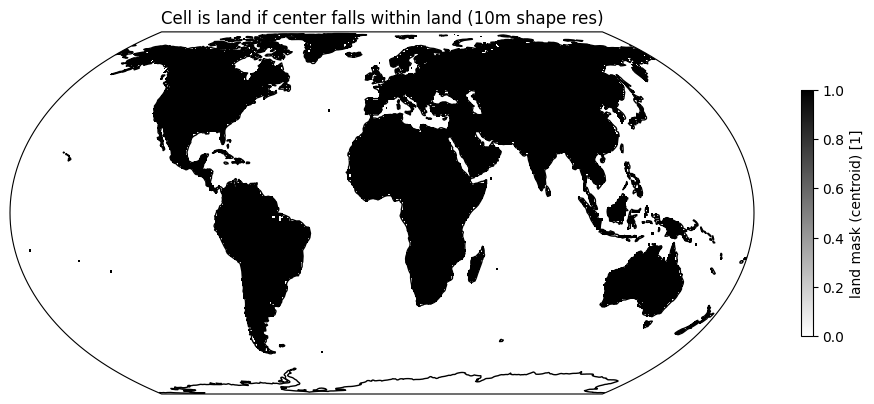

In [36]:
grid = xr.open_dataset("../prod/gchi_targetgrid_1x1_global_20260326.nc")
lons = grid.lon.values
lats = grid.lat.values
 
lons_180 = (lons + 180) % 360 - 180
lon2d, lat2d = np.meshgrid(lons_180, lats)
 
with fiona.open("/vsicurl/https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/10m_physical/ne_10m_land.shp") as src:
    geometries = [shape(f["geometry"]) for f in src]
 
land = unary_union(geometries)
mask = vectorized.contains(land, lon2d, lat2d)
 
ds = xr.DataArray(mask, coords=[lats, lons], dims=["lat", "lon"]).to_dataset(name="land_mask")
ds = ds.where(ds.lat > -60, 0) # mask antarctica

ds["lat"].attrs = {"units": "degrees_north", "standard_name": "latitude",  "long_name": "latitude",  "axis": "Y"}
ds["lon"].attrs = {"units": "degrees_east",  "standard_name": "longitude", "long_name": "longitude", "axis": "X"}
ds["land_mask"].attrs = {
    "long_name":     "land mask (centroid)",
    "standard_name": "land_binary_mask",
    "units":         "1",
    "flag_values":   "0 1",
    "flag_meanings":  "ocean land",
    "source":        "Natural Earth 10m land polygons (ne_10m_land.shp)",
    "method":        "centroid — cell is land only if cell centre falls within a land polygon",
}
ds.attrs = {
    "title":       "Land boolean mask (centroid method)",
}

ds.to_netcdf("../prod/land_mask_centroid_20260401.nc")


fig, ax = plt.subplots(figsize=(12,8),subplot_kw={"projection": ccrs.EqualEarth()})
ax.coastlines()
ds.land_mask.plot(cmap="binary", transform=ccrs.PlateCarree(), cbar_kwargs={"shrink":0.4})
plt.title("Cell is land if center falls within land (10m shape res)")

Written: ../prod/coastal_mask_any_touch_20260401.nc
Written: ../prod/coastal_mask_centroid_20260401.nc


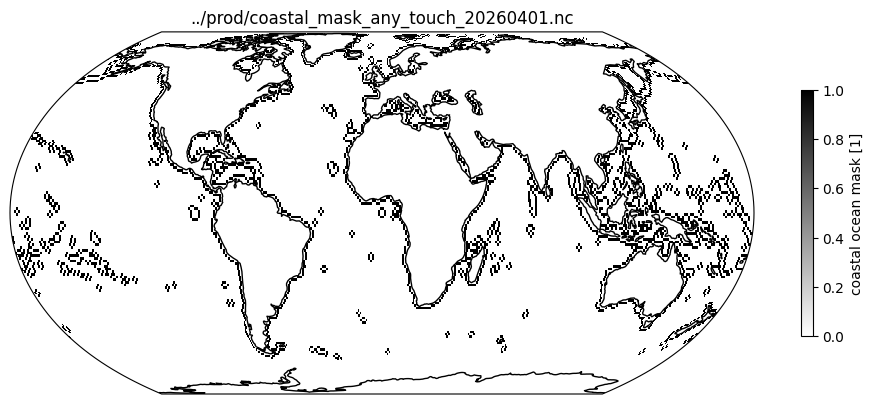

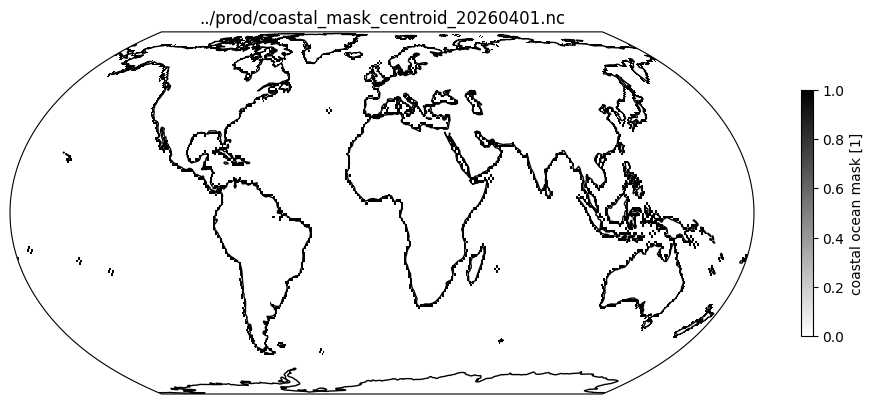

In [29]:
# create land masks under two different conditions: if centroid overlaps land OR if anywhere in cell touches land
for infile, outfile, varname in [
    ("/Volumes/Expansion/GCHI/inputs/maskdata/prod/land_mask_any_touch_20260401.nc", "/Volumes/Expansion/GCHI/inputs/maskdata/prod/coastal_mask_any_touch_20260401.nc", "land_mask"),
    ("/Volumes/Expansion/GCHI/inputs/maskdata/prod/land_mask_centroid_20260401.nc",  "/Volumes/Expansion/GCHI/inputs/maskdata/prod/coastal_mask_centroid_20260401.nc",  "land_mask"),
]:
    ds = xr.open_dataset(infile)
    mask = ds[varname].values.astype(bool)
    coastal = binary_dilation(mask) & ~mask

    out = xr.DataArray(coastal, coords=ds[varname].coords, dims=ds[varname].dims).to_dataset(name="coastal_mask")
    out = out.where(out.lat > -59.5, 0) # mask s. arctic
    out["lat"].attrs = ds["lat"].attrs
    out["lon"].attrs = ds["lon"].attrs
    out["coastal_mask"].attrs = {
        "long_name":     "coastal ocean mask",
        "standard_name": "land_binary_mask",
        "units":         "1",
        "flag_values":   "0 1",
        "flag_meanings": "open_ocean coastal_ocean",
        "method":        "1-cell binary dilation of land mask, land cells excluded",
        "source_mask":   infile,
    }
    out.attrs = {
        "title":       f"Coastal ocean mask derived from {infile}",
    }
    out.to_netcdf(outfile)
    
    fig, ax = plt.subplots(figsize=(12,8),subplot_kw={"projection": ccrs.EqualEarth()})
    ax.coastlines()
    out.coastal_mask.plot(cmap="binary", transform=ccrs.PlateCarree(), cbar_kwargs={"shrink":0.4})
    plt.title(outfile)
    print(f"Written: {outfile}")

# FWI infrequently burned areas  
see get_infreq_burned_areas_mask.py

## NDVI  
MODIS NDVI (2010-2014)

In [9]:
# GCHI global 1x1 model grid
target_grid = xr.open_dataset("/Volumes/Expansion/GCHI/inputs/maskdata/prod/gchi_targetgrid_1x1_global_20260326.nc")

In [16]:
ee.Authenticate()
ee.Initialize(project="ee-maxwellelling")

collection = (
    ee.ImageCollection("MODIS/MOD09GA_006_NDVI")
    .filterDate("2010-01-01", "2014-12-31")
    .filterBounds(ee.Geometry.BBox(-180, -90, 180, 90))
)

ds = geemap.ee_to_xarray(collection,  crs="EPSG:4326")
ds = ds.chunk({"time": -1, "lat": "auto", "lon": "auto"})
ds_mon = ds.resample(time="ME").mean().compute()

# use 2010-2014 NDVI climatology
ds_clim = ds_mon.groupby("time.month").mean()

In [19]:
# regrid to 1x1 default GCHI grid
def regrid(ds_in, regrid_to, method='bilinear'):
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True, ignore_degenerate=True)
    ds_out = regridder(ds_in)
    return ds_out
    
ds_clim_rg = regrid(ds_clim, target_grid, method='bilinear') # regrid to 1x1

/opt/homebrew/Caskroom/miniconda/base/envs/kitchensink/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


In [20]:
# VBD suitability mask = at least two consecutive months of NDVI above 0.125 (Ryan et al 2015; https://doi.org/10.1089/vbz.2015.1822)
green_areas = (ds_clim_rg["NDVI"] > 0.125).rolling(month=2).sum().max(dim="month") >= 2

Greater than 0.125 NDVI for at least two months (MODIS 2010-2014 climatology)


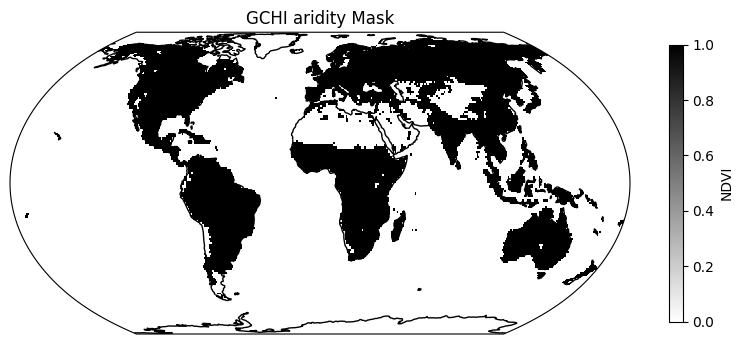

In [35]:
# mask plotted
fig,ax=plt.subplots(1,1,subplot_kw={'projection':ccrs.EqualEarth()}, figsize=(10, 6))
green_areas.plot(transform=ccrs.PlateCarree(), cmap="binary", cbar_kwargs={"shrink":0.6})
plt.title("GCHI aridity Mask")
ax.coastlines();
print("Greater than 0.125 NDVI for at least two months (MODIS 2010-2014 climatology)")

In [38]:
green_areas = green_areas.rename("aridity_mask").to_dataset()
green_areas.aridity_mask.attrs["units"] = "boolean"
green_areas.attrs["description"] = "Aridity mask based on 2010-2014 MODIS NDVI climatology. True if > than 0.125 NDVI for at least two months"
green_areas.attrs["cell_operations"] = "NDVI regridded to 1x1 degree grid (bilinear interpolation)"
green_areas.to_netcdf("/Volumes/Expansion/GCHI/inputs/maskdata/prod/gchi_aridity_mask_1x1_20260326.nc")

## Ozone daily to MDA8 scale factor calculation  
ERA5 (2023) 

In [ ]:
ds = xr.open_mfdataset("../../../era5_hourly/era5_ozone_1000hpa_hourly_2023*.nc")
target_grid = xr.open_dataset("../prod/gchi_targetgrid_1x1_global_20260326.nc")

# regrid to gchi grid 
def _regrid_xr(ds_in, regrid_to, method='bilinear'):
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True, ignore_degenerate=True)
    ds_out = regridder(ds_in)
    return ds_out

ds = _regrid_xr(ds, target_grid)

#ds = ds.where(ds.lat > -60, drop=True) # drop antarctica. not relvant 
max8hravg = ds.rolling(valid_time=8, min_periods=8).mean().resample(valid_time="1D").max()
dailyavg = ds.resample(valid_time="1D").mean()
mda8_v_day = dailyavg/max8hravg # fraction daily average of max 8-hour concentration
mda8_v_day = mda8_v_day.load()

In [1]:
# read era5 2023 hourly ozone data
ds = xr.open_mfdataset("era5_hourly/era5_ozone_1000hpa_hourly_2023*.nc")
ds = ds.where(ds.latitude > -60, drop=True) # drop antarctica. not relvant 
max8hravg = ds.rolling(valid_time=8, min_periods=8).mean().resample(valid_time="1D").max()
dailyavg = ds.resample(valid_time="1D").mean()
mda8_v_day = dailyavg/max8hravg

NameError: name 'xr' is not defined

Text(0.5, 1.0, '% daily average of MDA8')

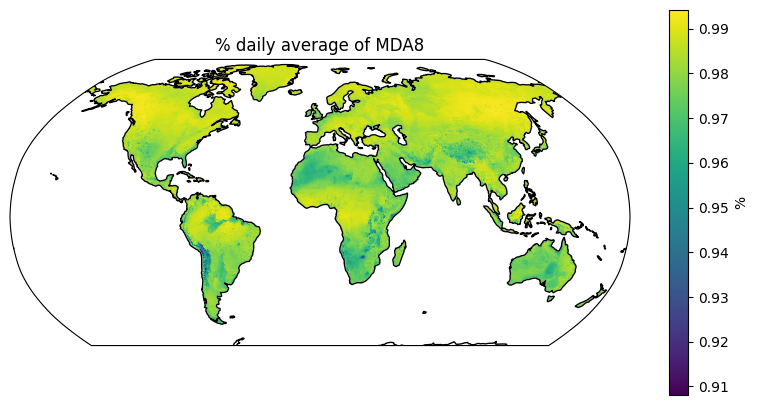

In [10]:
# spot check - map scale factor average over all months
fig, ax = plt.subplots(1,1, figsize=(10, 5), subplot_kw={'projection': ccrs.Robinson()})
#ax.set_extent([0, 360, -90, 90])
mda8_v_day.o3.mean("valid_time").plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={"label": "%"})
ax.coastlines(color="black", zorder=3)
ax.add_feature(cfeature.OCEAN, color="white", zorder=2)
plt.title("% daily average of MDA8")

In [11]:
# get statistics to see how scale factors vary globally over the months
mda8_v_day_t_avg = mda8_v_day.groupby("valid_time.month").mean("valid_time")
weights = np.cos(np.deg2rad(mda8_v_day_t_avg.lat))
range_weighted = mda8_v_day_t_avg.weighted(weights)
weighted_mean = range_weighted.mean(("lon", "lat")).load()

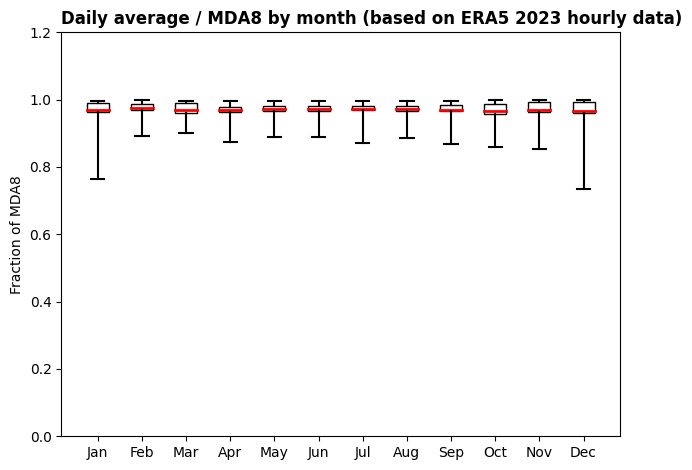

In [39]:
# box and whisker of scale factor values per month 
from matplotlib.patches import Rectangle

da = mda8_v_day.to_array().squeeze()  # assumes one variable

monthly = da.groupby("valid_time.month").mean()
stacked = monthly.stack(z=("lat","lon"))

w = np.cos(np.deg2rad(monthly.lat))
wmean = monthly.weighted(w).mean(("lat","lon"))

fig, ax = plt.subplots()

cap = 0.15   # half-width of whisker cap
boxw = 0.25  # half-width of box

for m in range(1, 13):
    v = stacked.sel(month=m).dropna("z")

    q25 = v.quantile(0.25).item()
    q75 = v.quantile(0.75).item()
    mean = wmean.sel(month=m).item()

    vmin = v.min().item()
    vmax = v.max().item()

    # box (IQR)
    ax.add_patch(Rectangle((m-boxw, q25), 2*boxw, q75-q25, fill=False))

    # weighted mean (center line)
    ax.plot([m-boxw, m+boxw], [mean, mean], 'r-', lw=2)

    # whiskers
    ax.plot([m, m], [vmin, q25], 'k-')
    ax.plot([m, m], [q75, vmax], 'k-')

    # whisker caps (horizontal lines)
    ax.plot([m-cap, m+cap], [vmin, vmin], 'k-')
    ax.plot([m-cap, m+cap], [vmax, vmax], 'k-')

ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Daily average / MDA8 by month (based on ERA5 2023 hourly data)", loc="left", weight="bold")
ax.set_ylim(0, 1.2)
ax.set_ylabel("Fraction of MDA8")
plt.tight_layout()
plt.show()

In [ ]:
# save dataset
mda8_v_day_clim = mda8_v_day.groupby("valid_time.month").mean().mean("pressure_level")
# get monthly mean
mda8_v_day_clim = mda8_v_day.groupby("valid_time.month").mean().mean("pressure_level")
# set attrs
ds_out = mda8_v_day_clim.copy().drop_vars("number")
ds_out.attrs.update({
    "title": "Monthly scale factor: daily-average O3 / MDA8 (ERA5, 2023, 1°×1° grid)",
    "summary": (
        "Monthly-mean ratio of 24h mean surface ozone concentration to the "
        "daily maximum 8-hour average (MDA8) ozone concentration, derived from "
        "ERA5 hourly reanalysis at 1000 hPa for the calendar year 2023 and "
        "regridded to a 1°×1° grid using bilinear interpolation."
    ),
    "source": "Global Climate Health Index V1",       
    "input_files": (
        "ERA5 hourly ozone mass mixing ratio at 1000 hPa, "
        "obtained from the Copernicus Climate Change Service (C3S) / ECMWF. "
        "Files: era5_ozone_1000hpa_hourly_2023*.nc"
    ),
    "processing_note": (
        "MDA8 computed with an 8-h rolling mean (min_periods=8) then daily max. "
        "Daily average computed as daily mean. "
        "Scale factor = daily_avg / MDA8, averaged over all days in each calendar month."
    ),
})

var_name = list(ds_out.data_vars)[0]
ds_out[var_name].attrs.update({
    "long_name": "Ratio of daily-mean O3 to MDA8 O3",
    "units": "1",
    "valid_min": 0.0,
    "valid_max": 2.0,
    "cell_methods": "time: mean within months",
    "comment": (
        "Derived as (24-h mean O3) / (daily max 8-h mean O3). "
    ),
})

ds_out["month"].attrs.update({"long_name": "Calendar month", "units": "1", "valid_range": [1, 12]})
if "lat" in ds_out.coords:
    ds_out["lat"].attrs.update({"long_name": "lat",  "units": "degrees_north", "standard_name": "lat"})
if "lon" in ds_out.coords:
    ds_out["lon"].attrs.update({"long_name": "lon", "units": "degrees_east",  "standard_name": "lon"})

ds_out.to_netcdf("../prod/mda8_daily_scalefac_jan-dec_era5_2023_20260401.nc")

# GenZ environmental zone mask Metzger (2013)

In [ ]:
GenS = xr.open_dataset("GEnSv3/gens_v3.tif")

# Load the attribute table
dbf = DBF('GEnSv3/GEnS_v3.dbf')
df = pd.DataFrame(iter(dbf))

df.columns

In [4]:
mapping = dict(zip(df['GEnS_seq'], df['GEnZ_seq']))

In [5]:
def map_values(x):
    return mapping.get(x, np.nan)  # fallback if no match

GenZ = GenS.copy().drop_vars("band_data")
GenZ['GenZ'] = xr.apply_ufunc(
    np.vectorize(map_values),
    GenS['band_data']
).rename({"x": "lon", "y": "lat"}).sortby(["lon", "lat"]).squeeze()
GenZ = GenZ.drop_dims(["x", "y"])

In [6]:
# 1x1 target grid 
tgt_ds = xr.open_dataset("../prod/gchi_targetgrid_1x1_global_20260326.nc")

In [7]:
# match GenZ to target grid lon 0-360
GenZ = GenZ.assign_coords(lon=(GenZ.lon % 360))
GenZ = GenZ.sortby('lon')

In [8]:
# go within each grid cell and get the most often category 
result = np.full((len(tgt_ds.lat), len(tgt_ds.lon)), np.nan, dtype=np.float32)

i_vals = []
j_vals = []
for i_ind, i in enumerate(tqdm(tgt_ds.lat.values)):
    lat_lo = i - 0.5
    lat_hi = i + 0.5
    i_vals.append(i)
    for j_ind, j in enumerate(tgt_ds.lon.values):
        lon_lo = j - 0.5
        lon_hi = j + 0.5
        j_vals.append(j)

        # get GenZ data in 1x1 grid 
        block = GenZ.sel(lat=slice(lat_lo, lat_hi), lon=slice(lon_lo, lon_hi)).GenZ.values
        vals, counts = np.unique(block, return_counts=True)

        if block.size == 0:
            result[i_ind, j_ind] = np.nan
        else:
            vals, counts = np.unique(block, return_counts=True)
            result[i_ind, j_ind] = vals[counts.argmax()]

da_regridded = xr.DataArray(result, dims=["lat","lon"], coords={"lat": tgt_ds.lat, "lon": tgt_ds.lon})

100%|███████████████████████████████████████████| 180/180 [00:15<00:00, 11.65it/s]


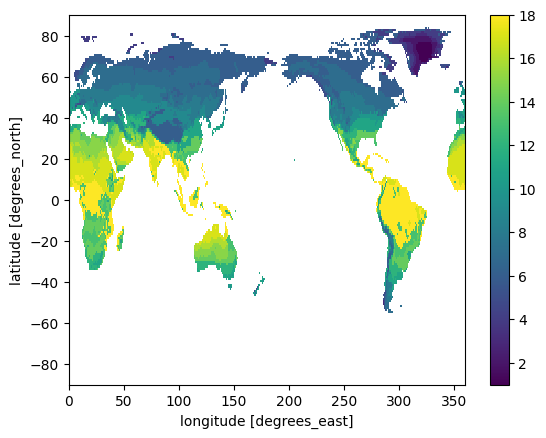

In [9]:
da_regridded.plot()

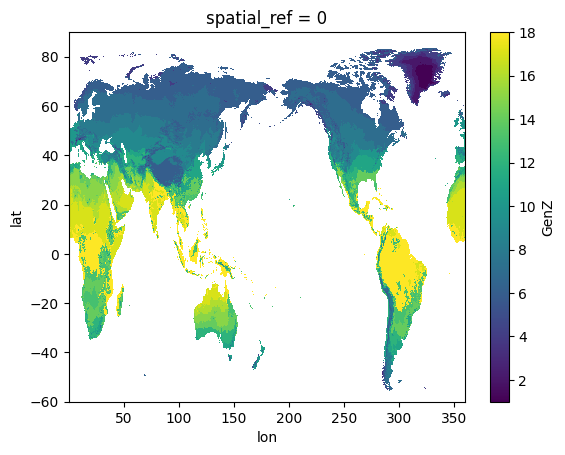

In [10]:
GenZ.GenZ.plot()

In [30]:
zone_descriptions = {
    4:  'D - Extremely cold and wet',
    5:  'E - Cold and wet',
    6:  'F - Extremely cold and mesic',
    7:  'G - Cold and mesic',
    8:  'H - Cool temperate and dry',
    9:  'I - Cool temperate and xeric',
    10: 'J - Cool temperate and moist',
    11: 'K - Warm temperate and mesic',
    12: 'L - Warm temperate and xeric',
    13: 'M - Hot and mesic',
    14: 'N - Hot and dry',
    15: 'O - Hot and arid (N thresholds applied)',
    16: 'P - Extremely hot and arid (Q thresholds applied)',
    17: 'Q - Extremely hot and xeric',
    18: 'R - Extremely hot and moist',
}

da_regridded.attrs = {
    'long_name'     : 'GenZ environmental zone classification (Metzger et al. 2013)',
    'units'         : '1',
    'zone_labels'   : str(zone_descriptions),
    'zone_note_15'  : 'Zone O (15) uses Zone N thresholds — not assigned in original paper',
    'zone_note_16'  : 'Zone P (16) uses Zone Q thresholds — not assigned in original paper',
    'valid_range'   : '1, 18',
    'source_dataset': 'https://datashare.ed.ac.uk/handle/10283/3089',
    'source_paper'  : 'Metzger et al. (2013), https://doi.org/10.1111/geb.12022',
    'threshold_ref' : 'https://iopscience.iop.org/article/10.1088/1748-9326/ad97cf#erlad97cffA1',
}

ds_genz = da_regridded.to_dataset(name='environmental_zone')

ds_genz.attrs = {
    'title'         : 'Global Environmental Zones (Metzger et al. 2013)',
    'summary'       : (
        'Environmental zone classification based on Metzger et al. (2013). '
        'Integer values 1–18 map to environmental zones A–R. '
        'Used to assign spatially varying fire weather index (FWI) hazard thresholds. '
        'Zones O (15) and P (16) were not assigned thresholds in the original paper and '
        'use N and Q thresholds respectively. '
    ),
    'source_dataset': 'https://datashare.ed.ac.uk/handle/10283/3089',
    'source_paper'  : 'Metzger et al. (2013), Global Ecology and Biogeography, https://doi.org/10.1111/geb.12022',
    'threshold_ref' : 'https://iopscience.iop.org/article/10.1088/1748-9326/ad97cf#erlad97cffA1',
}

ds_genz['lat'].attrs = {'long_name': 'latitude',  'units': 'degrees_north', 'axis': 'Y'}
ds_genz['lon'].attrs = {'long_name': 'longitude', 'units': 'degrees_east',  'axis': 'X'}

ds_genz.to_netcdf('../prod/environmental_zones_metzger2013_20260331.nc')

In [12]:
fwi_thresh = pd.read_csv("fwi_thresh_Kudlackova.csv")

In [13]:
# get levels 1-4 per env zone
fwi_thresh_dict = {}
for _, row in fwi_thresh.iterrows():
    letter_from_num = chr(ord('@')+row["GenZ_number"]) # number to letter 
    fwi_thresh_dict[letter_from_num] = [row["Moderate MIN"], row["High MIN"], row["Very high MIN"], row["Extreme MIN"]]

In [14]:
fwi = xr.open_dataset("../../testdata_fwi.nc")

In [15]:
def env_zone_thresh_exceedance(da, da_GenZ, var_name):
    da_GenZ_pt = da_GenZ.sel(lat=da.lat, lon=da.lon)
    env_letter = chr(ord('@') + int(da_GenZ_pt.values))
    da_levels = _annual_exceedance_frac(da, hazard_thresholds=FWI_THRESHOLDS[env_letter], var_name=var_name)
    return da_levels

In [16]:
import xesmf as xe
def _regrid_xr(ds_in, regrid_to, method='bilinear'):
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True, ignore_degenerate=True)
    ds_out = regridder(ds_in)
    return ds_out
target_grid = xr.open_dataset("../prod/gchi_targetgrid_1x1_global_20260326.nc")
fwi_rg = _regrid_xr(fwi, target_grid, method='bilinear') # regrid to 1x1

In [20]:
def _get_tsteps(da):
    """
    count tsteps in a year for annual fraction output
    """
    # get number of time steps in a year
    try:
        steps_per_year = da.groupby('time.year').count('time')
        # Number of time steps per year
        steps_per_year = da.groupby('time.year').count('time')
        steps_per_year.attrs["units"] = "time steps yr-1"
    except:
        steps_per_year = 365
        print("Number of time steps could not be calculated. Assuming input data are daily data.")

    return steps_per_year

def _ann_frac(da, steps_per_year):
    """
    Check the time resolution of a data array
    Useful for "fraction of year" calculation
    """
    ann_frac = da.groupby('time.year') / steps_per_year
    
    return ann_frac



In [21]:
import pandas as pd

# 1. Build (lat, lon, level) threshold DataArray
zone_letters = np.vectorize(lambda x: chr(ord('@') + int(x)) if not np.isnan(x) else None)(da_regridded.values)

thresh_array = np.full((*zone_letters.shape, 4), np.nan)
for i in range(zone_letters.shape[0]):
    for j in range(zone_letters.shape[1]):
        letter = zone_letters[i, j]
        if letter in fwi_thresh_dict:
            thresh_array[i, j, :] = fwi_thresh_dict[letter]

thresh_da = xr.DataArray(
    thresh_array,
    dims=['lat', 'lon', 'level'],
    coords={'lat': da_regridded.lat, 'lon': da_regridded.lon, 'level': [1,2,3,4]}
)

# 2. Exceedance per level — vectorised over all space at once
da_fwi = fwi_rg.__xarray_dataarray_variable__

da_list = []
for lvl in [1, 2, 3, 4]:
    th = thresh_da.sel(level=lvl)  # (lat, lon)
    da_count = (da_fwi > th).resample(time='1YE').sum('time')  # (lat, lon, year)
    da_list.append(da_count)

result = xr.concat(da_list, dim='level').assign_coords(level=[1,2,3,4])

# 3. Convert to annual fraction
steps_per_year = _get_tsteps(da_fwi)
result = _ann_frac(result, steps_per_year).rename('FWI')

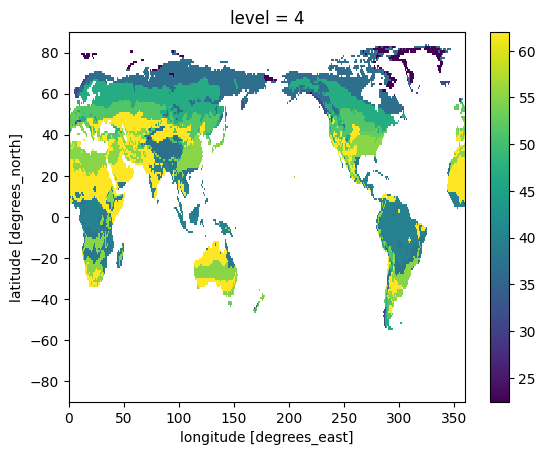

In [25]:
thresh_da.sel(level=4).plot()

In [27]:
# write attributes and save fwi thresholds to file 
import datetime

thresh_da.name = 'fwi_threshold'

thresh_da.attrs = {
    'long_name'      : 'FWI hazard threshold by environmental zone and danger level',
    'units'          : '1',
    'level_labels'   : '1: Moderate, 2: High, 3: Very High, 4: Extreme',
    'source_thresholds': 'Kudlackova et al. (2024), https://doi.org/10.1088/1748-9326/ad97cf (Appendix A1)',
    'source_zones'   : 'Metzger et al. (2013), Global Ecology and Biogeography, https://doi.org/10.1111/geb.12022',
    'zone_dataset'   : 'GEnS v3, https://datashare.ed.ac.uk/handle/10283/3089',
    'regrid_method'  : 'Majority class within each 1°×1° cell',
    'note'           : (
        'Thresholds vary spatially based on the dominant GEnZ environmental zone '
        'within each 1°×1° grid cell. Zones O (15) and P (16) use N and Q '
        'thresholds respectively (not assigned in Kudlackova et al. 2024).'
    ),
}

thresh_da['lat'].attrs = {'long_name': 'latitude',  'units': 'degrees_north', 'axis': 'Y'}
thresh_da['lon'].attrs = {'long_name': 'longitude', 'units': 'degrees_east',  'axis': 'X'}
thresh_da['level'].attrs = {
    'long_name' : 'FWI danger level',
    'units'     : '1',
    'flag_values': '1, 2, 3, 4',
    'flag_meanings': 'Moderate High Very_High Extreme',
}

ds_thresh = thresh_da.to_dataset()
ds_thresh.attrs = {
    'title'          : 'Spatially varying FWI hazard thresholds (Kudlackova et al. 2024)',
    'summary'        : (
        'Fire Weather Index (FWI) exceedance thresholds for four danger levels '
        '(Moderate, High, Very High, Extreme) assigned per grid cell based on the '
        'dominant GEnZ environmental zone (Metzger et al. 2013). '
        'Thresholds sourced from Kudlackova et al. (2024), Table A1.'
    ),
    'source_thresholds': 'Kudlackova et al. (2024), https://doi.org/10.1088/1748-9326/ad97cf',
    'source_zones'   : 'Metzger et al. (2013), https://doi.org/10.1111/geb.12022',
    'zone_dataset'   : 'GEnS v3, https://datashare.ed.ac.uk/handle/10283/3089',
}

ds_thresh.to_netcdf('../prod/gchi_fwi_thresholds_kudlackova2024_1x1_global_2060401.nc')